In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score




In [2]:
# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

In [3]:
# Features of interest: "Worst Area" and "Mean Concave Points"

worst_area_idx = list(data.feature_names).index("worst area")
mean_concave_points_idx = list(data.feature_names).index("mean concave points")
X = X[:, [mean_concave_points_idx, worst_area_idx]]

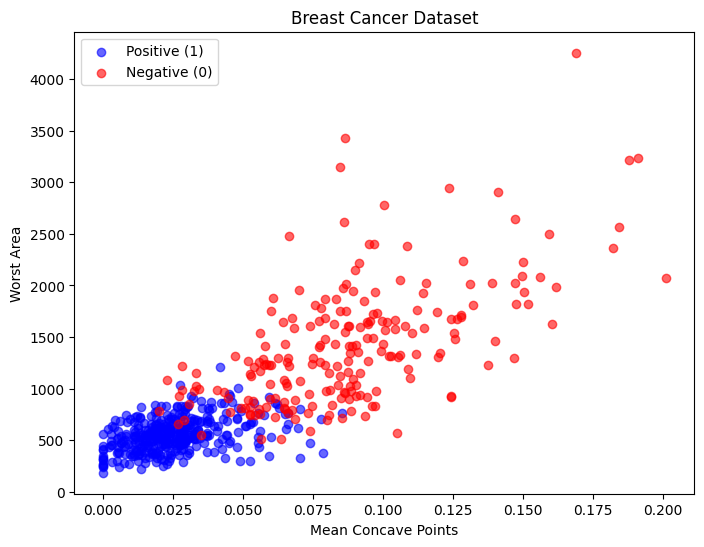

In [4]:
# Split positive and negative classes for visualization
pos = y == 1
neg = y == 0

plt.figure(figsize=(8, 6))
plt.scatter(X[pos, 0], X[pos, 1], color='b', label='Positive (1)', alpha=0.6)
plt.scatter(X[neg, 0], X[neg, 1], color='r', label='Negative (0)', alpha=0.6)
plt.xlabel("Mean Concave Points")
plt.ylabel("Worst Area")
plt.title("Breast Cancer Dataset")
plt.legend()
plt.show()

In [5]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Train Linear SVM classifiers
C_values = [0.1, 1000]
linear_svms = {}

for C in C_values:
    clf = SVC(kernel='linear', C=C)
    clf.fit(X_train, y_train)
    linear_svms[C] = clf

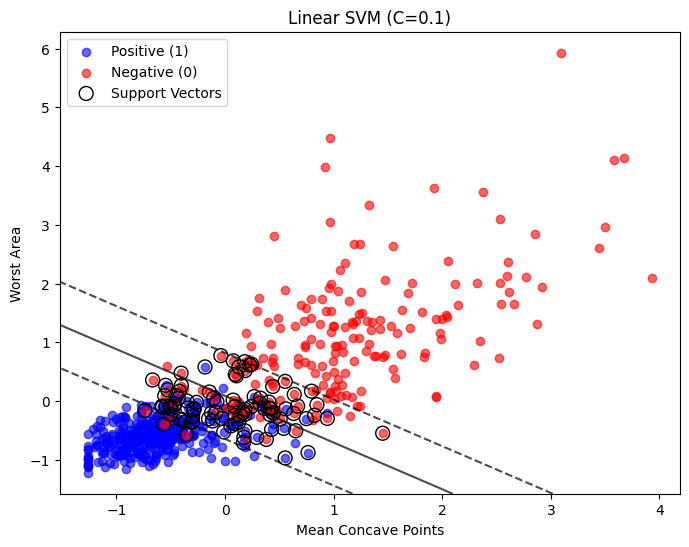

C=0.1:
  Number of Support Vectors: 94
  Training F1-Score: 0.9453125


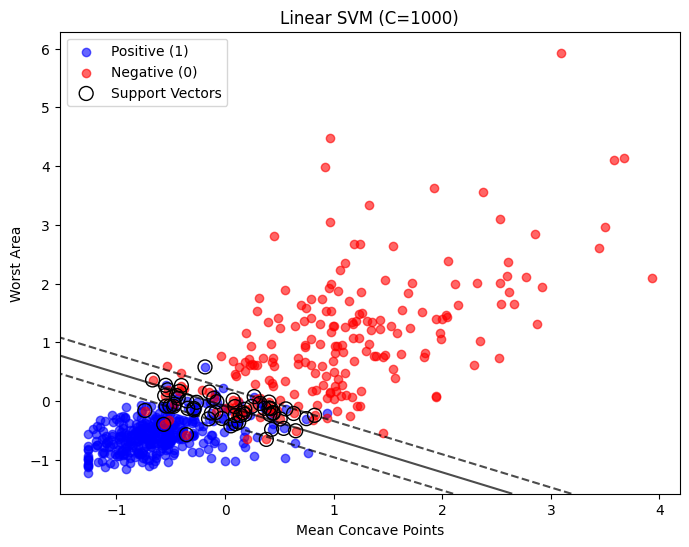

C=1000:
  Number of Support Vectors: 57
  Training F1-Score: 0.9561752988047809


In [6]:


# Visualize decision boundaries and margins
def plot_svm_decision_boundary(clf, X, y, title):
    plt.figure(figsize=(8, 6))
    
    # Plot data points
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='b', label='Positive (1)', alpha=0.6)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='r', label='Negative (0)', alpha=0.6)
    
    # Plot decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Create grid to evaluate model
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50), np.linspace(ylim[0], ylim[1], 50))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and margins
    plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.7, linestyles=['--', '-', '--'])
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='k', label='Support Vectors')
    
    plt.xlabel("Mean Concave Points")
    plt.ylabel("Worst Area")
    plt.title(title)
    plt.legend()
    plt.show()

for C, clf in linear_svms.items():
    plot_svm_decision_boundary(clf, X_scaled, y, f"Linear SVM (C={C})")
    print(f"C={C}:")
    print(f"  Number of Support Vectors: {len(clf.support_vectors_)}")
    print(f"  Training F1-Score: {f1_score(y_train, clf.predict(X_train))}")


In [7]:
# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 1, 10, 100],
}

# Train RBF SVM with Grid Search
rbf_svm = GridSearchCV(SVC(kernel='rbf'), param_grid, scoring='f1', cv=5)
rbf_svm.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.1, 1, 10, 100]},
             scoring='f1')

In [8]:
# Best parameters and performance
best_rbf = rbf_svm.best_estimator_
print("Best RBF SVM parameters:", rbf_svm.best_params_)
print("Number of Support Vectors:", len(best_rbf.support_vectors_))
print("Training F1-Score:", f1_score(y_train, best_rbf.predict(X_train)))

Best RBF SVM parameters: {'C': 10, 'gamma': 0.1}
Number of Support Vectors: 63
Training F1-Score: 0.9563492063492064


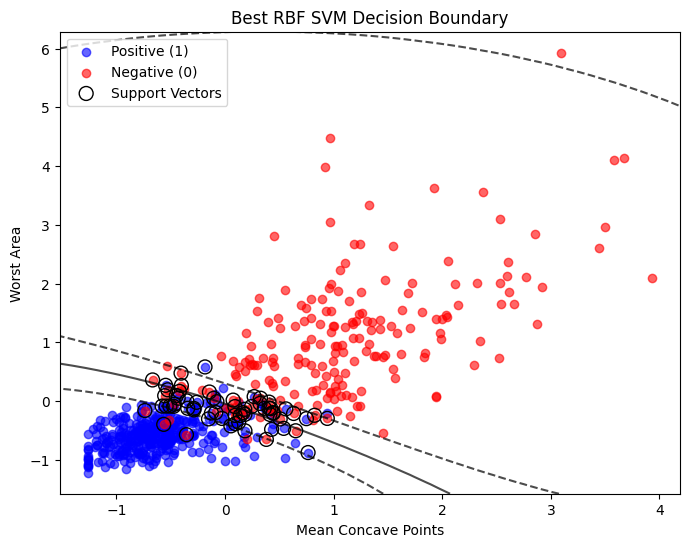

In [9]:
plot_svm_decision_boundary(best_rbf, X_scaled, y, "Best RBF SVM Decision Boundary")